# CS60010 Assignment 2 — Tiny Recursive Transformer for ARC-AGI

## Cell 1: Setup

In [1]:
# Cell 1: Install dependencies and set up Kaggle paths
import subprocess, sys, os

import torch
print(f"torch : {torch.__version__}")
print(f"CUDA  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

CHECKPOINT_DIR = '/kaggle/working/ARC_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"\nCheckpoint dir: {CHECKPOINT_DIR}")


torch : 2.10.0+cu128
CUDA  : True
GPU   : Tesla T4
VRAM  : 15.6 GB

Checkpoint dir: /kaggle/working/ARC_checkpoints


## Cell 2: Download ARC-AGI-1 Dataset

In [2]:
# Cell 2: Download ARC dataset from GitHub
import os, json

ARC_ROOT = '/kaggle/working/ARC-AGI'
if not os.path.exists(ARC_ROOT):
    os.system('git clone --quiet https://github.com/fchollet/ARC-AGI.git /kaggle/working/ARC-AGI')

TRAIN_DIR = '/kaggle/working/ARC-AGI/data/training'
EVAL_DIR  = '/kaggle/working/ARC-AGI/data/evaluation'

print(f"Training tasks  : {len(os.listdir(TRAIN_DIR))}")
print(f"Evaluation tasks: {len(os.listdir(EVAL_DIR))}")

# Sanity check
sample_file = sorted(os.listdir(TRAIN_DIR))[0]
with open(os.path.join(TRAIN_DIR, sample_file)) as f:
    sample = json.load(f)
demo = sample['train'][0]
print(f"Sample task      : {sample_file}")
print(f"  Demo pairs     : {len(sample['train'])}")
print(f"  Demo-0 in  sz  : {len(demo['input'])} x {len(demo['input'][0])}")
print(f"  Demo-0 out sz  : {len(demo['output'])} x {len(demo['output'][0])}")


Training tasks  : 400
Evaluation tasks: 400
Sample task      : 007bbfb7.json
  Demo pairs     : 5
  Demo-0 in  sz  : 3 x 3
  Demo-0 out sz  : 9 x 9


## Cell 3: Data Loading, Augmentation & Tokenisation

In [ ]:
# Cell 3: Data loading, augmentation, and tokenisation utilities
import os, json, random, math
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

# ── Constants ─────────────────────────────────────────────────────────────────
COLORS      = 10     # ARC colour palette 0–9
SEP_ID      = 10     # separator token between grids
Z_ID        = 11     # latent-state token (always at position 0 of sequence)
VOCAB_SIZE  = 12     # 10 colours + SEP + Z
MAX_SEQ_LEN = 2048   # keeps test-input/output tokens for up to 30x30 ARC grids
SEED        = 42

torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)


# ── Task loading ──────────────────────────────────────────────────────────────
def load_tasks(folder: str) -> list:
    """Return list of (task_name, task_dict) sorted by name."""
    tasks = []
    for fp in sorted(Path(folder).glob('*.json')):
        with open(fp) as f:
            tasks.append((fp.stem, json.load(f)))
    return tasks


# ── Dihedral augmentation (8 symmetries of the square) ───────────────────────
def apply_dihedral(grid: list, k: int) -> list:
    """
    k = 0..7: k%4 CCW rotations, k>=4 means horizontal-flip first.
    The 8 variants span the full dihedral group D4.
    """
    g = np.array(grid, dtype=np.int64)
    if k >= 4:
        g = np.fliplr(g); k -= 4
    g = np.rot90(g, k=k)
    return g.tolist()


# ── Color permutation augmentation ───────────────────────────────────────────
def color_permute_task(task: dict) -> dict:
    """
    Shuffle non-zero colour labels consistently across all grids in a task.
    Colour 0 (black/background) is always kept in place.
    Applied at 50% probability in the dataset.
    """
    all_colors = set()
    for pair in task['train'] + task.get('test', []):
        for key in ('input', 'output'):
            if key in pair:
                for row in pair[key]:
                    all_colors.update(row)
    all_colors.discard(0)
    colors = sorted(all_colors)
    perm   = colors.copy(); random.shuffle(perm)
    mapping = {0: 0, **dict(zip(colors, perm))}

    def remap(grid):
        return [[mapping.get(c, c) for c in row] for row in grid]

    new = {'train': [], 'test': []}
    for pair in task['train']:
        new['train'].append({'input': remap(pair['input']),
                             'output': remap(pair['output'])})
    for pair in task.get('test', []):
        p = {'input': remap(pair['input'])}
        if 'output' in pair: p['output'] = remap(pair['output'])
        new['test'].append(p)
    return new


# ── Output-shape inference ────────────────────────────────────────────────────
def infer_output_shape(task: dict, test_idx: int = 0):
    """
    Infer test-output dimensions from demo pairs.
    If all demo outputs share the same shape, use it; otherwise fall back to
    the test-input shape.
    """
    shapes = [(len(p['output']), len(p['output'][0])) for p in task['train']]
    if len(set(shapes)) == 1:
        return shapes[0]
    inp = task['test'][test_idx]['input']
    return len(inp), len(inp[0])


# ── Tokenisation (FIXED v2) ───────────────────────────────────────────────────
def tokenize_task(task: dict,
                  dihedral_k: int = 0,
                  use_color_perm: bool = False,
                  is_eval: bool = False,
                  task_idx: int = -1,
                  test_idx: int = 0):
    """
    Convert an ARC task to tensors for the RecursiveTransformer.

    Sequence layout:
      [Z]  [demo1_in] [SEP] [demo1_out] [SEP]
           [demo2_in] [SEP] [demo2_out] [SEP] ...
           [test_in]  [SEP] [test_out*]

    pair_idx encoding (FIX #2 – pair_idx=0 is ONLY for the Z token):
      Z token         → (0, 0, 0)
      demo-N input    → pair_idx = 2*N - 1   (1-based)
      demo-N output   → pair_idx = 2*N
      test input      → pair_idx = 2*len(demos) + 1
      test output     → pair_idx = 2*len(demos) + 2

    Truncation strategy (FIX #1):
      If the full sequence exceeds MAX_SEQ_LEN, drop entire demo pairs
      from the BACK (least-informative ones removed first).
      The Z token, the test-input section, and the test-output section
      are ALWAYS preserved so training signal is never lost.

    Returns:
      token_ids   : LongTensor (MAX_SEQ_LEN,)
      positions   : LongTensor (MAX_SEQ_LEN, 3)   – (row, col, pair_idx)
      targets     : LongTensor (MAX_SEQ_LEN,)      – -1 = no supervision
      output_mask : BoolTensor (MAX_SEQ_LEN,)      – True = test-output cell
    """
    if use_color_perm and random.random() < 0.5:
        task = color_permute_task(task)

    # ── Build each section independently so we can drop demos if needed ───────
    def grid_tokens(grid, pidx, targets_val):
        """Tokenise a single grid; targets_val=-1 for context, >=0 for output."""
        ids_, pos_, tgt_ = [], [], []
        for r, row in enumerate(grid):
            for c, color in enumerate(row):
                ids_.append(color)
                pos_.append((r, c, pidx))
                tgt_.append(targets_val if targets_val >= 0 else -1)
        # If this is the test-output section, fill actual target values
        return ids_, pos_, tgt_

    # Z token — pair_idx = 0 exclusively
    z_ids = [Z_ID]; z_pos = [(0, 0, 0)]; z_tgt = [-1]

    # Demo sections — pair_idx starts at 1
    demo_sections = []   # each element: (ids, pos, tgt)
    pidx = 1             # 1-indexed: Z occupies 0
    for pair in task['train']:
        inp = apply_dihedral(pair['input'],  dihedral_k)
        out = apply_dihedral(pair['output'], dihedral_k)
        sec_ids, sec_pos, sec_tgt = [], [], []

        # input grid
        i_, p_, t_ = grid_tokens(inp, pidx, -1)
        sec_ids += i_; sec_pos += p_; sec_tgt += t_
        pidx += 1
        sec_ids.append(SEP_ID); sec_pos.append((0, 0, pidx)); sec_tgt.append(-1)

        # output grid
        i_, p_, t_ = grid_tokens(out, pidx, -1)
        sec_ids += i_; sec_pos += p_; sec_tgt += t_
        pidx += 1
        sec_ids.append(SEP_ID); sec_pos.append((0, 0, pidx)); sec_tgt.append(-1)

        demo_sections.append((sec_ids, sec_pos, sec_tgt))

    # Test-input section
    test_inp = apply_dihedral(task['test'][test_idx]['input'], dihedral_k)
    ti_ids, ti_pos, ti_tgt = grid_tokens(test_inp, pidx, -1)
    pidx += 1
    ti_ids.append(SEP_ID); ti_pos.append((0, 0, pidx)); ti_tgt.append(-1)

    # Test-output section
    if is_eval:
        oh, ow = infer_output_shape(task, test_idx=test_idx)
        test_out    = [[0]*ow for _ in range(oh)]
        out_targets = [-1] * (oh * ow)   # no ground truth at eval time
    else:
        test_out    = apply_dihedral(task['test'][test_idx]['output'], dihedral_k)
        out_targets = [color for row in test_out for color in row]

    to_ids, to_pos, to_tgt = [], [], []
    for r, row in enumerate(test_out):
        for c, _ in enumerate(row):
            to_ids.append(0)            # placeholder — model will predict this
            to_pos.append((r, c, pidx))
            to_tgt.append(out_targets[r * len(row) + c])

    # ── Truncation: drop demo sections from the back until everything fits ────
    fixed_len = len(z_ids) + len(ti_ids) + len(to_ids)
    budget    = MAX_SEQ_LEN - fixed_len     # tokens available for demos

    kept_demos = []
    used = 0
    for sec in demo_sections:
        if used + len(sec[0]) <= budget:
            kept_demos.append(sec)
            used += len(sec[0])
        else:
            # Partially include this demo if no demos kept yet
            if not kept_demos:
                trunc = max(0, budget - used)
                kept_demos.append((sec[0][:trunc], sec[1][:trunc], sec[2][:trunc]))
            break   # no room for further demos

    # ── Assemble full sequence ────────────────────────────────────────────────
    ids, pos, tgt = list(z_ids), list(z_pos), list(z_tgt)
    for sec in kept_demos:
        ids += sec[0]; pos += sec[1]; tgt += sec[2]
    ids += ti_ids;  pos += ti_pos;  tgt += ti_tgt

    # Record where test-output tokens start (for output_mask)
    out_start = len(ids)
    ids += to_ids;  pos += to_pos;  tgt += to_tgt
    out_end = len(ids)

    # Hard-cap (should not be needed, but safety net)
    if len(ids) > MAX_SEQ_LEN:
        ids = ids[:MAX_SEQ_LEN]; pos = pos[:MAX_SEQ_LEN]; tgt = tgt[:MAX_SEQ_LEN]
        out_end = min(out_end, MAX_SEQ_LEN)

    # Pad to fixed length
    pad_len = MAX_SEQ_LEN - len(ids)
    ids += [0]*pad_len;  pos += [(0, 0, 0)]*pad_len;  tgt += [-1]*pad_len

    # Build output_mask positionally (True wherever test-output cells live)
    # This is correct for BOTH train and eval — independent of targets values.
    out_mask = [False]*MAX_SEQ_LEN
    for i in range(min(out_start, MAX_SEQ_LEN), min(out_end, MAX_SEQ_LEN)):
        out_mask[i] = True

    token_ids   = torch.tensor(ids,      dtype=torch.long)
    positions   = torch.tensor(pos,      dtype=torch.long)
    targets     = torch.tensor(tgt,      dtype=torch.long)
    output_mask = torch.tensor(out_mask, dtype=torch.bool)

    return token_ids, positions, targets, output_mask


# ── Dataset ───────────────────────────────────────────────────────────────────
class ARCDataset(Dataset):
    """
    ARC dataset with dihedral (×8) and colour-permutation augmentation.
    Returns (token_ids, positions, targets, output_mask, task_idx).
    task_idx is used by the model's per-task embedding table.
    """
    def __init__(self, task_list: list, augment: bool = True,
                 task_id_offset: int = 0):
        """
        task_id_offset: first task_idx assigned to this list.
          Training set → offset=0, so tasks get IDs 0..N_train-1.
          Val/eval → offset=-1 (unknown task; model uses zero-init embedding).
        """
        self.samples = []
        for local_idx, (_name, task) in enumerate(task_list):
            global_idx = local_idx + task_id_offset if task_id_offset >= 0 else -1
            if augment:
                for k in range(8):
                    self.samples.append((task, k, True, global_idx))
            else:
                self.samples.append((task, 0, False, global_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        task, k, aug, task_idx = self.samples[idx]
        ids, pos, tgt, omask = tokenize_task(
            task, dihedral_k=k, use_color_perm=aug, task_idx=task_idx)
        return ids, pos, tgt, omask, torch.tensor(task_idx, dtype=torch.long)


# ── Load tasks & split ────────────────────────────────────────────────────────
all_tasks  = load_tasks(TRAIN_DIR)
eval_tasks = load_tasks(EVAL_DIR)

random.shuffle(all_tasks)
n_val       = max(1, len(all_tasks) // 5)   # 20 % hold-out
val_tasks   = all_tasks[:n_val]
train_tasks = all_tasks[n_val:]

N_TRAIN_TASKS = len(train_tasks)   # used by the model's embedding table

print(f"Train tasks : {len(train_tasks)}  ({len(train_tasks)*8} augmented samples)")
print(f"Val tasks   : {len(val_tasks)}")
print(f"Eval tasks  : {len(eval_tasks)}")

# Sanity: verify test-output cells are preserved for a large-ish grid
ds_test = ARCDataset(train_tasks, augment=False, task_id_offset=0)
t0, p0, tg0, om0, tidx = ds_test[0]
n_out = om0.sum().item()
# Correct check:
#   Padding slots are legitimately stored as (token_id=0, row=0, col=0, pair_idx=0)
#   because that is the zero-fill value.  So pair_idx=0 will appear many times
#   (once for the Z token + once per padding slot).
#   The real invariant to verify: the ONLY token with pair_idx=0 that is NOT
#   the zero-fill pad value should be the single Z token (token_id = Z_ID = 11).
z_at_pidx0 = ((p0[:, 2] == 0) & (t0 == Z_ID)).sum().item()
pad_at_pidx0 = ((p0[:, 2] == 0) & (t0 == 0) & ~om0).sum().item()

print(f"\nSanity check (first task):")
print(f"  output_mask cells      : {n_out}  (should be > 0 for ALL tasks)")
print(f"  targets range          : [{tg0[om0].min().item()}, {tg0[om0].max().item()}]")
print(f"  Z token at pair_idx=0  : {z_at_pidx0}  (should be exactly 1)")
print(f"  pad slots at pair_idx=0: {pad_at_pidx0}  (expected, padding uses zero-fill)")
print(f"  total pair_idx=0 count : {(p0[:, 2] == 0).sum().item()}  (Z + padding)")
assert n_out > 0, "BUG: test-output section was truncated!"
assert z_at_pidx0 == 1, (
    f"BUG: Z token not found uniquely at pair_idx=0! z_at_pidx0={z_at_pidx0}")
# Verify no real content (non-Z, non-pad) accidentally has pair_idx=0
content_at_pidx0 = ((p0[:, 2] == 0) & (t0 != Z_ID) & (t0 != 0)).sum().item()
assert content_at_pidx0 == 0, (
    f"BUG: {content_at_pidx0} real content tokens have pair_idx=0 (should be 0)!")
print("✓ Tokenisation sanity checks passed")


Train tasks : 320  (2560 augmented samples)
Val tasks   : 80
Eval tasks  : 400

Sanity check (first task):
  output_mask cells      : 49  (should be > 0 for ALL tasks)
  targets range          : [1, 8]
  Z token at pair_idx=0  : 1  (should be exactly 1)
  pad slots at pair_idx=0: 208  (expected, padding uses zero-fill)
  total pair_idx=0 count : 209  (Z + padding)
✓ Tokenisation sanity checks passed


## Cell 4: Model Definition


In [ ]:
# Cell 4: Model definition
# ─────────────────────────────────────────────────────────────────────────────
# Tiny Recursive Transformer for ARC-AGI-1  (v2)
#
# Design choices (unchanged from v1):
#   1. One-hot colour embedding → linear projection  (colours are categorical)
#   2. 3-D RoPE: (row, col, pair_idx) per token
#   3. Bidirectional full-context attention (no causal mask)
#   4. Recursive refinement with separate z (latent) and y (answer) pathways
#   5. Deep supervision: CE loss at every refinement step t = 1..T
#
# ─────────────────────────────────────────────────────────────────────────────
import torch, torch.nn as nn, torch.nn.functional as F, math

# ── Architecture hyper-parameters ────────────────────────────────────────────
D_MODEL  = 256
N_HEADS  = 8
N_LAYERS = 6
FFN_DIM  = 1024
HEAD_DIM = D_MODEL // N_HEADS   # 32
T_TRAIN  = 5
T_INF    = 8

# 3-D RoPE split: d_row + d_col + d_pair = HEAD_DIM = 32
D_ROW, D_COL, D_PAIR = 12, 12, 8
assert D_ROW + D_COL + D_PAIR == HEAD_DIM and all(
    d % 2 == 0 for d in (D_ROW, D_COL, D_PAIR))


# ─────────────────────────────────────────────────────────────────────────────
# 3-D Rotary Position Embedding
# ─────────────────────────────────────────────────────────────────────────────
class ThreeDRoPE(nn.Module):
    """
    3-D Rotary Position Embeddings for ARC grids.

    HEAD_DIM=32 is split into three sub-spaces:
      d_row=12  → encodes which row within a grid
      d_col=12  → encodes which column within a grid
      d_pair=8  → encodes which demo pair / test the token belongs to

    Standard 1-D RoPE is applied independently in each sub-space using the
    corresponding index from the (row, col, pair_idx) triplet stored per token.
    """
    def __init__(self, max_row=32, max_col=32, max_pair=24):
        super().__init__()
        self.register_buffer('row_angles',  self._angles(D_ROW,  max_row),  persistent=False)
        self.register_buffer('col_angles',  self._angles(D_COL,  max_col),  persistent=False)
        self.register_buffer('pair_angles', self._angles(D_PAIR, max_pair), persistent=False)

    @staticmethod
    def _angles(dim: int, max_len: int) -> torch.Tensor:
        inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2).float() / dim))
        return torch.outer(torch.arange(max_len).float(), inv_freq)  # (max_len, dim//2)

    @staticmethod
    def _rotate_half(x: torch.Tensor) -> torch.Tensor:
        x1, x2 = x[..., 0::2], x[..., 1::2]
        return torch.stack([-x2, x1], dim=-1).flatten(-2)

    def _apply_rope(self, q, k, angles, idx):
        a   = angles[idx.clamp(0, angles.shape[0]-1)]   # (B, L, d//2)
        sin = a.sin().repeat_interleave(2, dim=-1).unsqueeze(2)  # (B,L,1,d)
        cos = a.cos().repeat_interleave(2, dim=-1).unsqueeze(2)
        q_r = q * cos.transpose(1,2) + self._rotate_half(q) * sin.transpose(1,2)
        k_r = k * cos.transpose(1,2) + self._rotate_half(k) * sin.transpose(1,2)
        return q_r, k_r

    def forward(self, q, k, positions):
        """
        q, k       : (B, H, L, HEAD_DIM)
        positions  : (B, L, 3)  — (row_idx, col_idx, pair_idx)
        """
        row_idx, col_idx, pair_idx = (positions[:,:,i] for i in range(3))
        q_r, q_c, q_p = q.split([D_ROW, D_COL, D_PAIR], dim=-1)
        k_r, k_c, k_p = k.split([D_ROW, D_COL, D_PAIR], dim=-1)
        q_r, k_r = self._apply_rope(q_r, k_r, self.row_angles,  row_idx)
        q_c, k_c = self._apply_rope(q_c, k_c, self.col_angles,  col_idx)
        q_p, k_p = self._apply_rope(q_p, k_p, self.pair_angles, pair_idx)
        return torch.cat([q_r, q_c, q_p], dim=-1), torch.cat([k_r, k_c, k_p], dim=-1)


# ─────────────────────────────────────────────────────────────────────────────
# Single Transformer Layer  (pre-norm, bidirectional, shared RoPE)
# ─────────────────────────────────────────────────────────────────────────────
class TransformerLayer(nn.Module):
    """
    Pre-norm transformer layer:
      x → LN → MHA (3-D RoPE) → residual → LN → FFN (GELU) → residual

    Bidirectional attention: the model sees the full sequence context.
    Padding mask is passed from outside and applied inside attention.
    """
    def __init__(self, rope: ThreeDRoPE):
        super().__init__()
        self.norm1 = nn.LayerNorm(D_MODEL)
        self.norm2 = nn.LayerNorm(D_MODEL)
        self.q = nn.Linear(D_MODEL, D_MODEL, bias=False)
        self.k = nn.Linear(D_MODEL, D_MODEL, bias=False)
        self.v = nn.Linear(D_MODEL, D_MODEL, bias=False)
        self.o = nn.Linear(D_MODEL, D_MODEL, bias=False)
        self.ffn = nn.Sequential(
            nn.Linear(D_MODEL, FFN_DIM), nn.GELU(), nn.Linear(FFN_DIM, D_MODEL))
        self.rope = rope

    def forward(self, x, positions, pad_mask=None):
        B, L, _ = x.shape
        h = self.norm1(x)
        Q = self.q(h).view(B, L, N_HEADS, HEAD_DIM).transpose(1, 2)
        K = self.k(h).view(B, L, N_HEADS, HEAD_DIM).transpose(1, 2)
        V = self.v(h).view(B, L, N_HEADS, HEAD_DIM).transpose(1, 2)
        Q, K = self.rope(Q, K, positions)
        attn = torch.matmul(Q, K.transpose(-2,-1)) / math.sqrt(HEAD_DIM)
        if pad_mask is not None:
            attn = attn.masked_fill(pad_mask.unsqueeze(1).unsqueeze(1), float('-inf'))
        attn = F.softmax(attn.float(), dim=-1).to(Q.dtype)
        out  = torch.matmul(attn, V).transpose(1,2).reshape(B, L, D_MODEL)
        x = x + self.o(out)
        x = x + self.ffn(self.norm2(x))
        return x


# ─────────────────────────────────────────────────────────────────────────────
# Recursive Transformer  (main model, v2)
# ─────────────────────────────────────────────────────────────────────────────
class RecursiveTransformer(nn.Module):
    """
    Tiny Recursive Transformer for ARC-AGI-1 (v2).

    Two states maintained across T recursive steps:
      z : global latent (256-dim) — the [Z] token at position 0
      y : per-cell output logits  — the test-output positions

    Per-task embeddings (new in v2):
      Each of the 400 training tasks has a dedicated learnable 256-dim vector
      added to the Z token's input at every recursive step.
      This gives the backbone a task-identity hint without parameter bloat
      (400 × 256 = 102 K parameters — negligible vs the 10 M backbone).
      At evaluation time task_idx = -1 → a fixed zero vector is used.
    """
    def __init__(self, n_train_tasks: int, T_train=T_TRAIN, T_inf=T_INF):
        super().__init__()
        self.T_train = T_train
        self.T_inf   = T_inf

        # One-hot → D_MODEL: treats colours as unordered categorical labels
        self.token_emb = nn.Linear(VOCAB_SIZE, D_MODEL, bias=False)

        # Separate pathway for current y-prediction re-embedding
        self.y_proj = nn.Linear(COLORS, D_MODEL, bias=False)

        # Per-task embedding table (index 0 = unknown/eval → always zero)
        # Training tasks use indices 1 .. n_train_tasks
        self.task_emb = nn.Embedding(n_train_tasks + 1, D_MODEL,
                                     padding_idx=0)   # idx=0 stays zero

        # Transformer backbone (shared across all T steps)
        self.rope   = ThreeDRoPE()
        self.layers = nn.ModuleList([TransformerLayer(self.rope)
                                     for _ in range(N_LAYERS)])
        self.norm   = nn.LayerNorm(D_MODEL)

        # Output head: cell-by-cell colour classification
        self.head = nn.Linear(D_MODEL, COLORS)

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
        # Keep the padding_idx row zero after init
        with torch.no_grad():
            self.task_emb.weight[0].zero_()

    def _pad_mask(self, token_ids, positions, output_mask):
        """
        True = padding position (should be ignored in attention).

        FIX v2: pair_idx == 0 is now EXCLUSIVELY the Z token (which is never
        padding), so we can safely use it as part of the padding heuristic
        without accidentally masking real demo-1 cells.

        A token is padding iff:
          • its pair_idx == 0  (only Z and true padding have this)
          • its token_id == 0  (colour black OR the zero-fill pad token)
          • it is NOT the Z token (position 0 in the sequence)
          • it is NOT an output cell (output cells also use placeholder 0)
        """
        is_zero_id   = (token_ids == 0)
        is_zero_pidx = (positions[:, :, 2] == 0)
        is_z_pos     = torch.zeros_like(is_zero_id)
        is_z_pos[:, 0] = True          # position 0 = Z token, never mask
        mask = is_zero_id & is_zero_pidx & ~is_z_pos & ~output_mask
        return mask

    def forward(self, token_ids, positions, output_mask,
                targets=None, task_idx=None):
        """
        token_ids   : (B, L) LongTensor
        positions   : (B, L, 3) LongTensor
        output_mask : (B, L) BoolTensor
        targets     : (B, L) LongTensor  or None
        task_idx    : (B,)   LongTensor  or None  (−1 → zero embedding)

        Returns (logits, loss) if targets given, else logits.
        loss = sum of per-step CE over all T recursive steps (deep supervision).
        """
        T = self.T_train if self.training else self.T_inf
        B, L = token_ids.shape
        dev  = token_ids.device

        pad_mask = self._pad_mask(token_ids, positions, output_mask)

        one_hot  = F.one_hot(token_ids, num_classes=VOCAB_SIZE).float()
        base_emb = self.token_emb(one_hot)   # (B, L, D)

        # Per-task embedding: clamp negative idx to 0 (→ zero vector via padding_idx)
        if task_idx is not None:
            tidx = task_idx.clamp(min=0).to(dev)   # (B,)
        else:
            tidx = torch.zeros(B, dtype=torch.long, device=dev)
        task_vec = self.task_emb(tidx)              # (B, D)

        # Initial states
        y_logits = torch.zeros(B, L, COLORS, device=dev, dtype=base_emb.dtype)
        z_state  = base_emb[:, 0:1, :].clone()     # (B, 1, D)

        total_loss = torch.zeros(1, device=dev)

        for _t in range(T):
            x = base_emb.clone()

            # ① Patch test-output positions with current y embedding
            y_emb = self.y_proj(F.softmax(y_logits, dim=-1))
            x     = torch.where(output_mask.unsqueeze(-1), y_emb, x)

            # ② Patch Z-token with current z state + per-task hint
            x[:, 0:1, :] = z_state + task_vec.unsqueeze(1)

            # ③ Transformer forward
            for layer in self.layers:
                x = layer(x, positions, pad_mask)
            x = self.norm(x)

            # ④ Update z and y
            z_state  = x[:, 0:1, :]
            y_logits = self.head(x)   # (B, L, 10)

            # ⑤ Deep supervision: accumulate CE at every step
            if targets is not None:
                sup = output_mask & (targets >= 0)
                if sup.any():
                    total_loss = total_loss + F.cross_entropy(
                        y_logits[sup].float(), targets[sup])

        if targets is not None:
            return y_logits, total_loss
        return y_logits

    @torch.no_grad()
    def predict(self, token_ids, positions, output_mask,
                task_idx=None, attempt: int = 1):
        """
        attempt=1 → greedy argmax
        attempt=2 → sample from top-3 (encourages diversity for 2nd attempt)
        """
        self.eval()
        logits = self.forward(token_ids, positions, output_mask,
                              task_idx=task_idx)   # (B, L, 10)
        if attempt == 1:
            return logits.argmax(dim=-1)
        top3_vals, top3_idx = logits.topk(3, dim=-1)
        probs = F.softmax(top3_vals.float(), dim=-1)
        samp  = torch.multinomial(probs.reshape(-1, 3), 1).reshape(logits.shape[:2])
        return top3_idx.gather(-1, samp.unsqueeze(-1)).squeeze(-1)


# ─────────────────────────────────────────────────────────────────────────────
# Instantiate model
# ─────────────────────────────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
model  = RecursiveTransformer(n_train_tasks=N_TRAIN_TASKS,
                               T_train=T_TRAIN, T_inf=T_INF).to(DEVICE)
print(f"Model on: {DEVICE}")
print(f"Architecture: d={D_MODEL}, heads={N_HEADS}, layers={N_LAYERS}, "
      f"ffn={FFN_DIM}, T_train={T_TRAIN}, T_inf={T_INF}")


Model on: cuda
Architecture: d=256, heads=8, layers=6, ffn=1024, T_train=5, T_inf=8


## Cell 5: Parameter Count

In [5]:
# Cell 5: Parameter count (must be ≤ 50M)
def count_params(m):
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable

total_p, train_p = count_params(model)
print(f"Total parameters     : {total_p:>12,}")
print(f"Trainable parameters : {train_p:>12,}")
print(f"Budget remaining     : {50_000_000 - total_p:>12,}  (50 M limit)")
print()

components = {
    'token_emb  (one-hot 12→256)'   : model.token_emb,
    'y_proj     (logits 10→256)'    : model.y_proj,
    'task_emb   (N_train+1 × 256)'  : model.task_emb,
    'transformer layers (×6)'       : model.layers,
    'final LayerNorm'               : model.norm,
    'output_head (256→10)'          : model.head,
}
print(f"{'Component':<40} {'Parameters':>12}")
print("-" * 55)
for name, mod in components.items():
    n = sum(p.numel() for p in mod.parameters())
    print(f"{name:<40} {n:>12,}")
print("-" * 55)
print(f"{'TOTAL':<40} {total_p:>12,}")

assert total_p <= 50_000_000, f"EXCEEDS 50M budget! {total_p:,}"
print("\n✓ Within 50 M parameter budget")


Total parameters     :    4,823,306
Trainable parameters :    4,823,306
Budget remaining     :   45,176,694  (50 M limit)

Component                                  Parameters
-------------------------------------------------------
token_emb  (one-hot 12→256)                     3,072
y_proj     (logits 10→256)                      2,560
task_emb   (N_train+1 × 256)                   82,176
transformer layers (×6)                     4,732,416
final LayerNorm                                   512
output_head (256→10)                            2,570
-------------------------------------------------------
TOTAL                                       4,823,306

✓ Within 50 M parameter budget


## Cell 6: Training Loop

**Fix 5** — 80 epochs instead of 50.  
All other hyper-parameters unchanged; BF16 + gradient clipping for T4 safety.

Total training steps : 51200
Steps per epoch      : 640

Starting training for 80 epochs...
 Epoch |     Loss |  Val Acc |        LR |   Time
-------------------------------------------------------
     1 |   6.8009 |   0.0000 |  3.00e-04 | 213.1s
     2 |   5.1920 |   0.0286 |  3.00e-04 | 223.6s
     3 |   4.7440 |   0.0286 |  2.99e-04 | 223.1s
     4 |   4.4853 |   0.0571 |  2.98e-04 | 224.2s
     5 |   4.2123 |   0.0286 |  2.98e-04 | 223.6s
     6 |   3.9998 |   0.0286 |  2.96e-04 | 224.0s
     7 |   3.7998 |   0.0571 |  2.95e-04 | 223.5s
     8 |   3.6933 |   0.0286 |  2.93e-04 | 223.6s
     9 |   3.5893 |   0.0571 |  2.92e-04 | 223.9s
    10 |   3.5160 |   0.0000 |  2.90e-04 | 223.8s
    11 |   3.3874 |   0.0857 |  2.87e-04 | 223.5s
    12 |   3.2966 |   0.0857 |  2.85e-04 | 223.4s
    13 |   3.3025 |   0.0286 |  2.82e-04 | 223.1s
    14 |   3.1875 |   0.0571 |  2.79e-04 | 223.5s
    15 |   3.1023 |   0.0286 |  2.76e-04 | 223.5s
    16 |   3.0013 |   0.0571 |  2.73e-04 | 223.5s
  

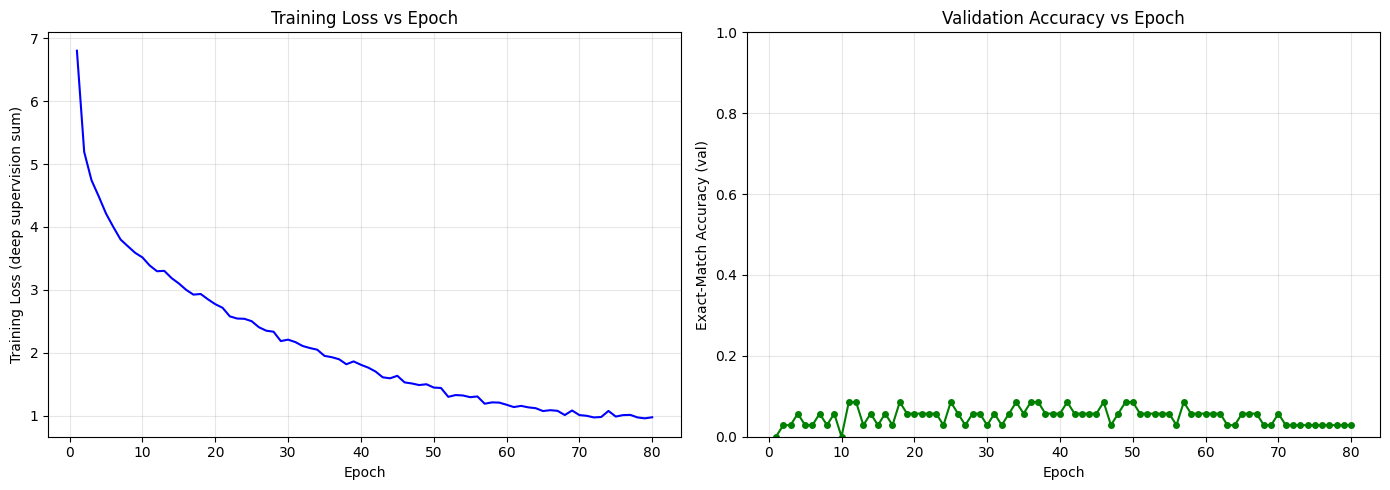

In [ ]:
# Cell 6: Training loop
import time
import matplotlib.pyplot as plt

# ── Hyper-parameters (training) ───────────────────────────────────────────────
LR_BASE    = 3e-4
LR_MIN     = 1e-5
WEIGHT_DEC = 0.01
WARMUP_S   = 200      # steps
N_EPOCHS   = 80       
BATCH_SIZE = 4        

# ── Data loaders ──────────────────────────────────────────────────────────────
train_ds = ARCDataset(train_tasks, augment=True,  task_id_offset=0)
val_ds   = ARCDataset(val_tasks,   augment=False, task_id_offset=-1)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False,
                          num_workers=2, pin_memory=True)

total_steps = N_EPOCHS * len(train_loader)
print(f"Total training steps : {total_steps}")
print(f"Steps per epoch      : {len(train_loader)}")

# ── Optimizer & LR schedule (linear warmup → cosine decay) ───────────────────
optimizer = torch.optim.AdamW(model.parameters(),
                               lr=LR_BASE, weight_decay=WEIGHT_DEC)

def lr_lambda(step: int) -> float:
    if step < WARMUP_S:
        return step / max(1, WARMUP_S)
    progress = (step - WARMUP_S) / max(1, total_steps - WARMUP_S)
    cosine   = 0.5 * (1.0 + math.cos(math.pi * progress))
    return LR_MIN / LR_BASE + (1.0 - LR_MIN / LR_BASE) * cosine

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = torch.amp.GradScaler('cuda', enabled=(DEVICE == 'cuda'))


# ── Exact-match accuracy helper ───────────────────────────────────────────────
def exact_match_acc(mdl, loader, max_batches=None) -> float:
    """
    A task is 'correct' only if every output cell is predicted correctly
    (either attempt 1 or attempt 2).
    """
    mdl.eval()
    correct = total = 0
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if max_batches and i >= max_batches:
                break
            ids, pos, tgt, omask, tidx = batch
            ids, pos, tgt, omask, tidx = (
                ids.to(DEVICE), pos.to(DEVICE), tgt.to(DEVICE),
                omask.to(DEVICE), tidx.to(DEVICE))

            sup = omask & (tgt >= 0)
            if not sup.any():
                continue

            for attempt in (1, 2):
                pred = mdl.predict(ids, pos, omask,
                                   task_idx=tidx, attempt=attempt)
                if (pred[sup] == tgt[sup]).all().item():
                    correct += 1; break
            total += 1
    return correct / total if total > 0 else 0.0


# ── Training loop ─────────────────────────────────────────────────────────────
train_losses   = []
val_accuracies = []
step           = 0
best_val_acc   = 0.0

print(f"\nStarting training for {N_EPOCHS} epochs...")
print(f"{'Epoch':>6} | {'Loss':>8} | {'Val Acc':>8} | {'LR':>9} | {'Time':>6}")
print("-" * 55)

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    t_start    = time.time()
    n_batches  = 0

    for ids, pos, tgt, omask, tidx in train_loader:
        ids, pos, tgt, omask, tidx = (
            ids.to(DEVICE), pos.to(DEVICE), tgt.to(DEVICE),
            omask.to(DEVICE), tidx.to(DEVICE))

        optimizer.zero_grad()
        with torch.autocast(device_type=DEVICE, dtype=torch.bfloat16,
                            enabled=(DEVICE == 'cuda')):
            _, loss = model(ids, pos, omask, tgt, task_idx=tidx)

        if loss.requires_grad:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

        scheduler.step()
        epoch_loss += loss.item()
        n_batches  += 1
        step       += 1

    avg_loss = epoch_loss / max(1, n_batches)
    train_losses.append(avg_loss)

    # Quick validation (first 40 tasks, fast)
    val_acc = exact_match_acc(model, val_loader, max_batches=40)
    val_accuracies.append(val_acc)

    elapsed = time.time() - t_start
    curr_lr = optimizer.param_groups[0]['lr']
    print(f"{epoch:>6} | {avg_loss:>8.4f} | {val_acc:>8.4f} | "
          f"{curr_lr:>9.2e} | {elapsed:>5.1f}s")

    # Save best checkpoint
    if val_acc >= best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_acc': val_acc,
            'train_loss': avg_loss,
        }, f"{CHECKPOINT_DIR}/best_model.pt")

    # Periodic epoch checkpoint (for resuming across sessions)
    if epoch % 20 == 0:
        torch.save(model.state_dict(),
                   f"{CHECKPOINT_DIR}/epoch_{epoch}.pt")

print(f"\nBest validation accuracy: {best_val_acc:.4f}  ({best_val_acc*100:.2f}%)")

# ── Training curves ───────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(range(1, N_EPOCHS+1), train_losses, 'b-', linewidth=1.5)
ax1.set(xlabel='Epoch', ylabel='Training Loss (deep supervision sum)',
        title='Training Loss vs Epoch'); ax1.grid(True, alpha=0.3)
ax2.plot(range(1, N_EPOCHS+1), val_accuracies, 'g-o', linewidth=1.5, markersize=4)
ax2.set(xlabel='Epoch', ylabel='Exact-Match Accuracy (val)',
        title='Validation Accuracy vs Epoch', ylim=(0,1)); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CHECKPOINT_DIR}/training_curves.png", dpi=150)
plt.show()


## Cell 7: Full Validation Accuracy (held-out 20% of training tasks)

In [ ]:
# Cell 7: Full validation accuracy on all held-out tasks
ckpt = torch.load(f"{CHECKPOINT_DIR}/best_model.pt", map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f"Loaded checkpoint: epoch {ckpt['epoch']},  val_acc={ckpt['val_acc']:.4f}")

model.eval()
correct, total = 0, 0
details = []

with torch.no_grad():
    for name, task in val_tasks:
        task_correct = True
        n_cases = len(task.get('test', []))
        for case_idx in range(n_cases):
            ids, pos, tgt, omask = tokenize_task(task, is_eval=False, test_idx=case_idx)
            ids   = ids.unsqueeze(0).to(DEVICE)
            pos   = pos.unsqueeze(0).to(DEVICE)
            tgt   = tgt.unsqueeze(0).to(DEVICE)
            omask = omask.unsqueeze(0).to(DEVICE)
            tidx  = torch.tensor([-1], dtype=torch.long, device=DEVICE)

            sup = omask & (tgt >= 0)
            if not sup.any():
                continue

            case_correct = False
            for attempt in (1, 2):
                pred = model.predict(ids, pos, omask, task_idx=tidx, attempt=attempt)
                if (pred[sup] == tgt[sup]).all().item():
                    case_correct = True; break
            if not case_correct:
                task_correct = False
                break

        correct += int(task_correct); total += 1
        details.append((name, task_correct))

val_acc = correct / total if total > 0 else 0.0
print(f"\nValidation exact-match accuracy: {correct}/{total} = "
      f"{val_acc:.4f}  ({val_acc*100:.2f}%)")

solved = [n for n, ok in details if ok]
print(f"\nCorrectly solved tasks ({len(solved)}):")
for n in solved[:15]: print(f"  {n}")
if len(solved) > 15: print(f"  ... and {len(solved)-15} more")


Loaded checkpoint: epoch 57,  val_acc=0.0857

Validation exact-match accuracy: 4/74 = 0.0541  (5.41%)

Correctly solved tasks (4):
  6d58a25d
  d631b094
  de1cd16c
  d9fac9be


## Cell 8: Final Evaluation on 400 Evaluation Tasks

**Fix 4** — TTT increased from 10 → 50 gradient steps with a warm learning rate.  
Only task *inputs* are used during inference; ground-truth outputs are read only for accuracy scoring at the end.

In [ ]:
# Cell 8: Final evaluation on 400 evaluation tasks
# ─────────────────────────────────────────────────────────────────────────────
# Test-Time Training (TTT):
# For each eval task, briefly fine-tune the model on that task's demo pairs
# (without ever touching the test output), then generate predictions.
#
# ─────────────────────────────────────────────────────────────────────────────
import copy, time

TTT_STEPS = 50      
TTT_LR    = 3e-4    

# Load best checkpoint before eval
ckpt = torch.load(f"{CHECKPOINT_DIR}/best_model.pt", map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
base_state = copy.deepcopy(model.state_dict())
print(f"Loaded best checkpoint: epoch {ckpt['epoch']},  val_acc={ckpt['val_acc']:.4f}")


def test_time_train(mdl, task, device, n_steps=TTT_STEPS, lr=TTT_LR):
    """
    Fine-tune `mdl` in-place for n_steps on the demo pairs of `task`.

    Strategy: hold out one demo pair as the 'test' target and use the
    remaining pairs as context (standard ARC TTT trick).
    Dihedral augmentation and colour permutation are applied each step
    for variety.  task_idx=-1 (zero embedding) throughout — we don't
    have a trained embedding for eval tasks.
    """
    mdl.train()
    opt = torch.optim.AdamW(mdl.parameters(), lr=lr, weight_decay=0.01)
    sc  = torch.amp.GradScaler('cuda', enabled=(device == 'cuda'))

    for _s in range(n_steps):
        k = random.randint(0, 7)
        if len(task['train']) < 2:
            pseudo = task
        else:
            split  = random.randint(1, len(task['train']) - 1)
            pseudo = {'train': task['train'][:split],
                      'test':  [task['train'][split]]}

        ids, pos, tgt, omask = tokenize_task(
            pseudo, dihedral_k=k, use_color_perm=True, is_eval=False)
        ids   = ids.unsqueeze(0).to(device)
        pos   = pos.unsqueeze(0).to(device)
        tgt   = tgt.unsqueeze(0).to(device)
        omask = omask.unsqueeze(0).to(device)
        tidx  = torch.tensor([-1], dtype=torch.long, device=device)

        opt.zero_grad()
        with torch.autocast(device_type=device, dtype=torch.bfloat16,
                            enabled=(device == 'cuda')):
            _, loss = mdl(ids, pos, omask, tgt, task_idx=tidx)

        if loss.requires_grad:
            sc.scale(loss).backward()
            sc.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(mdl.parameters(), 1.0)
            sc.step(opt); sc.update()

    return mdl


def grid_from_mask(pred: torch.Tensor, omask: torch.Tensor,
                   out_h: int, out_w: int) -> list:
    """Extract predicted output cells and reshape to 2-D grid."""
    flat = pred[omask].cpu().tolist()
    if len(flat) < out_h * out_w:
        flat += [0] * (out_h * out_w - len(flat))
    return [flat[r*out_w:(r+1)*out_w] for r in range(out_h)]


# ── Evaluation loop ───────────────────────────────────────────────────────────
eval_predictions = {}
correct_eval     = 0
n_eval           = len(eval_tasks)

print(f"\nEvaluating {n_eval} tasks (TTT = {TTT_STEPS} steps each)...")
print(f"{'Task':>6} | {'Running Acc':>12} | {'Elapsed':>8} | {'ETA':>8}")
print("-" * 50)
t_start = time.time()

for i, (name, task) in enumerate(eval_tasks):

    # ── TTT: fine-tune on this task's demos ───────────────────────────────
    model.load_state_dict(base_state)
    model = test_time_train(model, task, DEVICE)
    model.eval()

    predictions  = []

    # ── Attempt 1 & 2 (inputs only: is_eval=True) ─────────────────────────
    task_correct = True
    for case_idx in range(len(task.get('test', []))):
        out_h, out_w = infer_output_shape(task, test_idx=case_idx)
        ids, pos, tgt, omask = tokenize_task(task, is_eval=True, test_idx=case_idx)
        ids   = ids.unsqueeze(0).to(DEVICE)
        pos   = pos.unsqueeze(0).to(DEVICE)
        omask = omask.unsqueeze(0).to(DEVICE)
        tidx  = torch.tensor([-1], dtype=torch.long, device=DEVICE)

        case_predictions = {}
        with torch.no_grad():
            for attempt in (1, 2):
                pred = model.predict(ids, pos, omask, task_idx=tidx, attempt=attempt)
                case_predictions[f"attempt_{attempt}"] = grid_from_mask(
                    pred[0], omask[0], out_h, out_w)
        predictions.append(case_predictions)

        # ── Score against ground truth (available in the JSON) ────────────────
        # Note: this is for local accuracy reporting only; the official eval
        # uses the JSON submitted to the ARC evaluation harness.
        ids_gt, pos_gt, tgt_gt, omask_gt = tokenize_task(
            task, is_eval=False, test_idx=case_idx)
        ids_gt   = ids_gt.unsqueeze(0).to(DEVICE)
        pos_gt   = pos_gt.unsqueeze(0).to(DEVICE)
        tgt_gt   = tgt_gt.unsqueeze(0).to(DEVICE)
        omask_gt = omask_gt.unsqueeze(0).to(DEVICE)
        tidx_gt  = torch.tensor([-1], dtype=torch.long, device=DEVICE)

        sup_gt = omask_gt & (tgt_gt >= 0)
        case_correct = False
        if sup_gt.any():
            with torch.no_grad():
                for attempt in (1, 2):
                    pred = model.predict(ids_gt, pos_gt, omask_gt,
                                         task_idx=tidx_gt, attempt=attempt)
                    if (pred[sup_gt] == tgt_gt[sup_gt]).all().item():
                        case_correct = True; break
        if not case_correct:
            task_correct = False

    eval_predictions[name] = predictions
    correct_eval += int(task_correct)

    model.load_state_dict(base_state)   # restore for next task

    if (i+1) % 50 == 0 or (i+1) == n_eval:
        elapsed     = time.time() - t_start
        running_acc = correct_eval / (i+1) * 100
        eta         = elapsed / (i+1) * (n_eval - i - 1)
        print(f"{i+1:>6} | {running_acc:>11.2f}% | {elapsed:>7.0f}s | {eta:>7.0f}s")

eval_acc = correct_eval / n_eval * 100
print(f"\n{'='*50}")
print(f"Final Evaluation Exact-Match Accuracy: "
      f"{correct_eval}/{n_eval}  ({eval_acc:.2f}%)")
print(f"{'='*50}")

# Save predictions JSON
pred_path = f"{CHECKPOINT_DIR}/eval_predictions.json"
with open(pred_path, 'w') as f:
    json.dump(eval_predictions, f)
print(f"\nSaved predictions → {pred_path}")


Loaded best checkpoint: epoch 57,  val_acc=0.0857

Evaluating 400 tasks (TTT = 50 steps each)...
  Task |  Running Acc |  Elapsed |      ETA
--------------------------------------------------
    50 |        2.00% |     382s |    2677s
   100 |        2.00% |     759s |    2277s
   150 |        1.33% |    1149s |    1914s
   200 |        1.50% |    1550s |    1550s
   250 |        2.00% |    1935s |    1161s
   300 |        2.00% |    2315s |     772s
   350 |        2.29% |    2703s |     386s
   400 |        3.25% |    3073s |       0s

Final Evaluation Exact-Match Accuracy: 13/400  (3.25%)

Saved predictions → /kaggle/working/ARC_checkpoints/eval_predictions.json


## Cell 9: Ablation Study

Three ablations, each trained for 15 epochs to estimate the contribution of key design choices.

Running ablations (15 epochs each, quick comparison)...
  Ablation 1: No Deep Supervision                     val_acc = 0.0270
  Ablation 2: 1-D Sinusoidal PE (no 3-D RoPE)         val_acc = 0.0000
  Ablation 3: Single Forward Pass (T=1)               val_acc = 0.0405

  ABLATION RESULTS (validation exact-match, 15-epoch ablation runs)
  Full Model (3-D RoPE + deep sup + T=5 recursion + task emb)     5.41%
  Ablation 1: No deep supervision (loss at T only)                2.70%
  Ablation 2: 1-D sinusoidal PE (no 3-D RoPE)                     0.00%
  Ablation 3: Single pass T=1 (no recursive refinement)           4.05%
  Deep supervision impact     : +2.70%
  3-D RoPE vs 1-D sin impact : +5.41%
  Recursive refinement impact : +1.35%


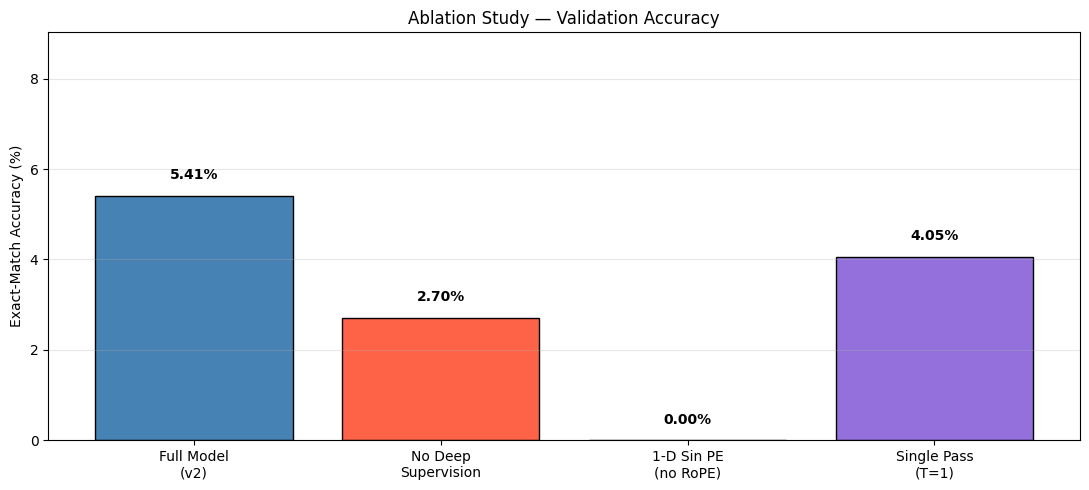


✓ All results saved.


In [9]:
# Cell 9: Ablation study
# ─────────────────────────────────────────────────────────────────────────────
# Ablation 1: No deep supervision  (CE loss only at final step T)
# Ablation 2: 1-D sinusoidal PE    (replace 3-D RoPE with flat sinusoidal)
# Ablation 3: Single forward pass  (T=1, no recursive refinement, no z state)
#
# All ablations inherit the v2 tokenisation fixes.
# ─────────────────────────────────────────────────────────────────────────────

# ── Ablation 1: No deep supervision ──────────────────────────────────────────
class RecursiveTransformerNoDSup(RecursiveTransformer):
    """Ablation: CE loss only at the FINAL recursive step (not every step)."""
    def forward(self, token_ids, positions, output_mask,
                targets=None, task_idx=None):
        T = self.T_train if self.training else self.T_inf
        B, L = token_ids.shape
        dev  = token_ids.device
        pad_mask = self._pad_mask(token_ids, positions, output_mask)

        one_hot  = F.one_hot(token_ids, num_classes=VOCAB_SIZE).float()
        base_emb = self.token_emb(one_hot)
        tidx     = (task_idx.clamp(min=0).to(dev) if task_idx is not None
                    else torch.zeros(B, dtype=torch.long, device=dev))
        task_vec = self.task_emb(tidx)

        y_logits = torch.zeros(B, L, COLORS, device=dev, dtype=base_emb.dtype)
        z_state  = base_emb[:, 0:1, :].clone()

        for _t in range(T):
            x = base_emb.clone()
            x = torch.where(output_mask.unsqueeze(-1),
                            self.y_proj(F.softmax(y_logits, dim=-1)), x)
            x[:, 0:1, :] = z_state + task_vec.unsqueeze(1)
            for layer in self.layers: x = layer(x, positions, pad_mask)
            x = self.norm(x)
            z_state = x[:, 0:1, :]
            y_logits = self.head(x)

        # Loss only at final step
        if targets is not None:
            sup  = output_mask & (targets >= 0)
            loss = (F.cross_entropy(y_logits[sup].float(), targets[sup])
                    if sup.any() else torch.zeros(1, device=dev))
            return y_logits, loss
        return y_logits


# ── Ablation 2: 1-D sinusoidal PE (no 3-D RoPE) ──────────────────────────────
class SinusoidalPE(nn.Module):
    def __init__(self, d_model=D_MODEL, max_len=MAX_SEQ_LEN):
        super().__init__()
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe)
    def forward(self, x):
        return x + self.pe[:x.shape[1]].unsqueeze(0)

class TransformerLayerNoRoPE(nn.Module):
    """Standard transformer layer without RoPE (PE added to embeddings outside)."""
    def __init__(self):
        super().__init__()
        self.norm1 = nn.LayerNorm(D_MODEL); self.norm2 = nn.LayerNorm(D_MODEL)
        self.q = nn.Linear(D_MODEL, D_MODEL, bias=False)
        self.k = nn.Linear(D_MODEL, D_MODEL, bias=False)
        self.v = nn.Linear(D_MODEL, D_MODEL, bias=False)
        self.o = nn.Linear(D_MODEL, D_MODEL, bias=False)
        self.ffn = nn.Sequential(
            nn.Linear(D_MODEL, FFN_DIM), nn.GELU(), nn.Linear(FFN_DIM, D_MODEL))

    def forward(self, x, positions=None, pad_mask=None):
        B, L, _ = x.shape
        h = self.norm1(x)
        Q = self.q(h).view(B, L, N_HEADS, HEAD_DIM).transpose(1,2)
        K = self.k(h).view(B, L, N_HEADS, HEAD_DIM).transpose(1,2)
        V = self.v(h).view(B, L, N_HEADS, HEAD_DIM).transpose(1,2)
        attn = (Q @ K.transpose(-2,-1)) / math.sqrt(HEAD_DIM)
        if pad_mask is not None:
            attn = attn.masked_fill(pad_mask.unsqueeze(1).unsqueeze(1), float('-inf'))
        attn = F.softmax(attn.float(), dim=-1).to(Q.dtype)
        x = x + self.o((attn @ V).transpose(1,2).reshape(B, L, D_MODEL))
        x = x + self.ffn(self.norm2(x))
        return x

class RecursiveTransformerSinPE(RecursiveTransformer):
    """Ablation: replace 3-D RoPE with 1-D sinusoidal absolute PE."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.sin_pe = SinusoidalPE()
        self.layers  = nn.ModuleList([TransformerLayerNoRoPE() for _ in range(N_LAYERS)])
        self.rope    = None

    def forward(self, token_ids, positions, output_mask,
                targets=None, task_idx=None):
        T = self.T_train if self.training else self.T_inf
        B, L = token_ids.shape; dev = token_ids.device
        pad_mask = self._pad_mask(token_ids, positions, output_mask)
        one_hot  = F.one_hot(token_ids, num_classes=VOCAB_SIZE).float()
        base_emb = self.sin_pe(self.token_emb(one_hot))
        tidx     = (task_idx.clamp(min=0).to(dev) if task_idx is not None
                    else torch.zeros(B, dtype=torch.long, device=dev))
        task_vec = self.task_emb(tidx)
        y_logits = torch.zeros(B, L, COLORS, device=dev, dtype=base_emb.dtype)
        z_state  = base_emb[:, 0:1, :].clone()
        total_loss = torch.zeros(1, device=dev)
        for _t in range(T):
            x = base_emb.clone()
            x = torch.where(output_mask.unsqueeze(-1),
                            self.y_proj(F.softmax(y_logits, dim=-1)), x)
            x[:, 0:1, :] = z_state + task_vec.unsqueeze(1)
            for layer in self.layers: x = layer(x, positions, pad_mask)
            x = self.norm(x); z_state = x[:, 0:1, :]; y_logits = self.head(x)
            if targets is not None:
                sup = output_mask & (targets >= 0)
                if sup.any():
                    total_loss = total_loss + F.cross_entropy(
                        y_logits[sup].float(), targets[sup])
        if targets is not None: return y_logits, total_loss
        return y_logits


# ── Ablation 3: Single forward pass (T=1, no recursion) ──────────────────────
class SinglePassTransformer(nn.Module):
    """Ablation: T=1 single pass — no z-state, no recursive refinement."""
    def __init__(self, n_train_tasks):
        super().__init__()
        self.token_emb = nn.Linear(VOCAB_SIZE, D_MODEL, bias=False)
        self.task_emb  = nn.Embedding(n_train_tasks + 1, D_MODEL, padding_idx=0)
        self.rope      = ThreeDRoPE()
        self.layers    = nn.ModuleList([TransformerLayer(self.rope) for _ in range(N_LAYERS)])
        self.norm      = nn.LayerNorm(D_MODEL)
        self.head      = nn.Linear(D_MODEL, COLORS)
        for p in self.parameters():
            if p.dim() > 1: nn.init.xavier_uniform_(p)
        with torch.no_grad(): self.task_emb.weight[0].zero_()

    def _pad_mask(self, token_ids, positions, output_mask):
        is_z = torch.zeros_like(token_ids, dtype=torch.bool)
        is_z[:, 0] = True
        return ((token_ids == 0) & (positions[:,:,2] == 0)
                & ~is_z & ~output_mask)

    def forward(self, token_ids, positions, output_mask, targets=None, task_idx=None):
        B, L = token_ids.shape; dev = token_ids.device
        pad_mask = self._pad_mask(token_ids, positions, output_mask)
        tidx     = (task_idx.clamp(min=0).to(dev) if task_idx is not None
                    else torch.zeros(B, dtype=torch.long, device=dev))
        x = self.token_emb(F.one_hot(token_ids, num_classes=VOCAB_SIZE).float())
        x[:, 0:1, :] += self.task_emb(tidx).unsqueeze(1)
        for layer in self.layers: x = layer(x, positions, pad_mask)
        x = self.norm(x); logits = self.head(x)
        if targets is not None:
            sup  = output_mask & (targets >= 0)
            loss = (F.cross_entropy(logits[sup].float(), targets[sup])
                    if sup.any() else torch.zeros(1, device=dev))
            return logits, loss
        return logits

    @torch.no_grad()
    def predict(self, token_ids, positions, output_mask, task_idx=None, attempt=1):
        self.eval()
        logits = self.forward(token_ids, positions, output_mask, task_idx=task_idx)
        if attempt == 1: return logits.argmax(dim=-1)
        top3v, top3i = logits.topk(3, dim=-1)
        probs = F.softmax(top3v.float(), dim=-1)
        samp  = torch.multinomial(probs.reshape(-1,3), 1).reshape(logits.shape[:2])
        return top3i.gather(-1, samp.unsqueeze(-1)).squeeze(-1)


# ── Train & evaluate each ablation (15 quick epochs) ─────────────────────────
ABLATION_EPOCHS = 15

def run_ablation(abl_model, label):
    abl_model = abl_model.to(DEVICE)
    opt   = torch.optim.AdamW(abl_model.parameters(),
                               lr=LR_BASE, weight_decay=WEIGHT_DEC)
    sched = torch.optim.lr_scheduler.LambdaLR(
        opt, lambda s: min(1.0, s / max(1, WARMUP_S)))
    sc    = torch.amp.GradScaler('cuda', enabled=(DEVICE == 'cuda'))
    abl_model.train()

    for epoch in range(1, ABLATION_EPOCHS + 1):
        for ids, pos, tgt, omask, tidx in train_loader:
            ids, pos, tgt, omask, tidx = (
                ids.to(DEVICE), pos.to(DEVICE), tgt.to(DEVICE),
                omask.to(DEVICE), tidx.to(DEVICE))
            opt.zero_grad()
            with torch.autocast(device_type=DEVICE, dtype=torch.bfloat16,
                                enabled=(DEVICE=='cuda')):
                _, loss = abl_model(ids, pos, omask, tgt, task_idx=tidx)
            if loss.requires_grad:
                sc.scale(loss).backward()
                sc.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(abl_model.parameters(), 1.0)
                sc.step(opt); sc.update()
            sched.step()

    acc = exact_match_acc(abl_model, val_loader, max_batches=80)
    print(f"  {label:<50}  val_acc = {acc:.4f}")
    return acc

print("Running ablations (15 epochs each, quick comparison)...")
print("=" * 70)

abl1_acc = run_ablation(RecursiveTransformerNoDSup(n_train_tasks=N_TRAIN_TASKS),
                         "Ablation 1: No Deep Supervision")
abl2_acc = run_ablation(RecursiveTransformerSinPE(n_train_tasks=N_TRAIN_TASKS),
                         "Ablation 2: 1-D Sinusoidal PE (no 3-D RoPE)")
abl3_acc = run_ablation(SinglePassTransformer(n_train_tasks=N_TRAIN_TASKS),
                         "Ablation 3: Single Forward Pass (T=1)")

# Full model (re-evaluate from best checkpoint)
model.load_state_dict(base_state)
full_acc = exact_match_acc(model, val_loader, max_batches=80)

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  ABLATION RESULTS (validation exact-match, 15-epoch ablation runs)")
print("=" * 70)
rows = [
    ("Full Model (3-D RoPE + deep sup + T=5 recursion + task emb)", full_acc),
    ("Ablation 1: No deep supervision (loss at T only)",             abl1_acc),
    ("Ablation 2: 1-D sinusoidal PE (no 3-D RoPE)",                 abl2_acc),
    ("Ablation 3: Single pass T=1 (no recursive refinement)",        abl3_acc),
]
for label, acc in rows:
    print(f"  {label:<60}  {acc*100:>6.2f}%")
print("=" * 70)
print(f"  Deep supervision impact     : {(full_acc-abl1_acc)*100:+.2f}%")
print(f"  3-D RoPE vs 1-D sin impact : {(full_acc-abl2_acc)*100:+.2f}%")
print(f"  Recursive refinement impact : {(full_acc-abl3_acc)*100:+.2f}%")

# Bar chart
fig, ax = plt.subplots(figsize=(11, 5))
labels  = ['Full Model\n(v2)', 'No Deep\nSupervision', '1-D Sin PE\n(no RoPE)', 'Single Pass\n(T=1)']
values  = [full_acc, abl1_acc, abl2_acc, abl3_acc]
colors_b = ['steelblue', 'tomato', 'orange', 'mediumpurple']
bars = ax.bar(labels, [v*100 for v in values], color=colors_b, edgecolor='black')
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{v*100:.2f}%', ha='center', va='bottom', fontweight='bold')
ax.set(ylabel='Exact-Match Accuracy (%)', title='Ablation Study — Validation Accuracy',
       ylim=(0, max(values)*100*1.3 + 2))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CHECKPOINT_DIR}/ablation_results.png", dpi=150)
plt.show()
print("\n✓ All results saved.")
